In [257]:
#importing relevant packages
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import os
from astropy.table import Table, join

In [16]:
homedir = os.getenv("HOME")
wisesize_path = homedir+'/Desktop/wisesize/SGA2025/'

sga2025 = Table.read(wisesize_path+'SGA2025-v1.0.fits',hdu=1)
phot = Table.read(wisesize_path+'SGA2025-v1.0.fits',hdu=2)
tractor = Table.read(wisesize_path+'SGA2025-v1.0.fits',hdu=3)

In [52]:
#step one, isolate the sample within our redshift slice (0.002 < z < 0.025)
z = sga2025['Z']
zflag = (z>0.002) & (z<0.025)
print(f"Number of galaxies with redshifts: {sum(z>0)} ({sum(z>0)*100./len(z):.2f}% of SGA2025)")
print(f"Number of galaxies within WISESize redshifts: {sum(zflag)} ({sum(zflag)*100./len(z):.2f}% of SGA2025)")

Number of galaxies with redshifts: 309646 (65.79% of SGA2025)
Number of galaxies within WISESize redshifts: 47772 (10.15% of SGA2025)


In [57]:
sga2025_z = sga2025[zflag]

In [80]:
#create empty parent catalog with OBJIDs
def create_OBJIDs(unique_cat):
    formatted_strings = np.array([f"OBJID{num:05}" for num in np.arange(0,len(unique_cat))])
    unique_cat['OBJID'] = formatted_strings  #add the new column
    return unique_cat
wisesize = Table({'OBJID': np.zeros(len(sga2025_z), dtype=str)}) #sga2025_z is the SGA2025 catalog with the aforementioned Z cut
wisesize = create_OBJIDs(wisesize)

In [81]:
#add some SGA2025 columns
sga_cols = ['SGAID','GROUP_NAME','GROUP_MULT','GROUP_PRIMARY','RA','DEC','BA','PA']
for col in sga_cols:
    wisesize[col] = sga2025_z[col]

In [197]:
#create RA, DEC boolean flags to indicate whether the galaxies lie within the WISESize area
#87◦ < R.A. < 300◦
#−10◦ < decl. < 85◦
raflag = (wisesize['RA']>87.) & (wisesize['RA']<300.)
decflag = (wisesize['DEC']>-10.) & (wisesize['DEC']<85.)
print(f"Number of WISESize galaxies within RA & DEC: {sum(raflag&decflag)} "
      f"({sum(raflag&decflag)*100./len(wisesize):.2f}% of WISESize)")
wisesize['RAflag'], wisesize['DECflag'] = raflag, decflag

Number of WISESize galaxies within RA & DEC: 22558 (47.22% of WISESize)


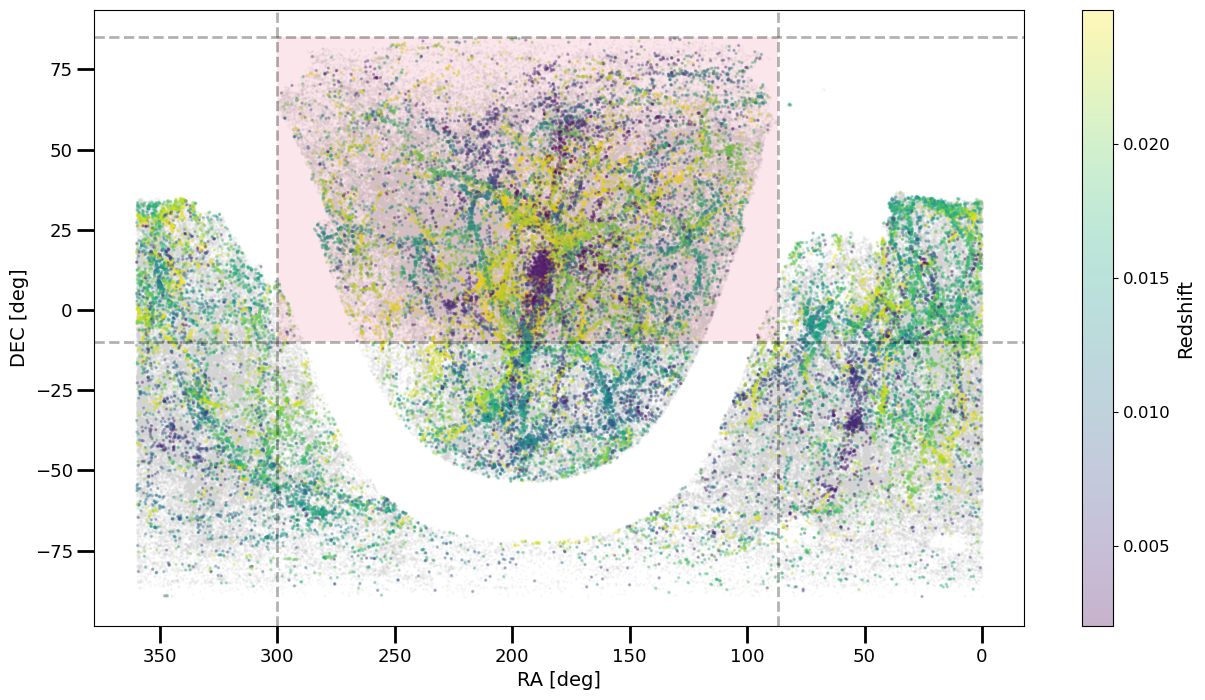

In [198]:
fig, ax = plt.subplots(figsize=(15,8))
ax.invert_xaxis()

dat1 = ax.scatter(sga2025['RA'], sga2025['DEC'], color='lightgray', alpha=0.1, s=1)
dat2 = ax.scatter(sga2025_z['RA'], sga2025_z['DEC'], c=sga2025_z['Z'], alpha=0.3, s=2)

ax.axhline(-10,alpha=0.3,lw=2,ls='--',color='black')
ax.axhline(85,alpha=0.3,lw=2,ls='--',color='black')
ax.axvline(87,alpha=0.3,lw=2,ls='--',color='black')
ax.axvline(300,alpha=0.3,lw=2,ls='--',color='black')

rect = patches.Rectangle((87,-10), width=300-87,           # Width along the x-axis
    height=95,facecolor='crimson', edgecolor='None', alpha=0.1)
ax.add_patch(rect)

cbar = fig.colorbar(dat2, ax=ax)
cbar.set_label('Redshift', size=14)
cbar.ax.tick_params(labelsize=12)

ax.tick_params(axis='x', length=12, width=2, labelsize=13)
ax.tick_params(axis='y', length=12, width=2, labelsize=13)
ax.set_xlabel('RA [deg]',fontsize=14)
ax.set_ylabel('DEC [deg]',fontsize=14)

plt.show()

In [242]:
#define the 12-micron SNR flags -- need AP01 and AP03

ap01_flux = phot['FLUX_AP01_W3'][zflag]
ap03_flux = phot['FLUX_AP03_W3'][zflag]

ap01_err = phot['FLUX_ERR_AP01_W3'][zflag]
ap03_err = phot['FLUX_ERR_AP03_W3'][zflag]

snr_ap01 = ap01_flux / ap01_err
snr_ap03 = ap03_flux / ap03_err

snr_ap01_flag = (snr_ap01 > 10.)
snr_ap03_flag = (snr_ap03 > 10.)

/var/folders/gx/q5wqxlgs0rgfm6f87vgxlgyw4s52w0/T/ipykernel_62417/2242792758.py:9: RuntimeWarning: invalid value encountered in divide
  snr_ap01 = ap01_flux / ap01_err
/var/folders/gx/q5wqxlgs0rgfm6f87vgxlgyw4s52w0/T/ipykernel_62417/2242792758.py:10: RuntimeWarning: invalid value encountered in divide
  snr_ap03 = ap03_flux / ap03_err


In [243]:
wisesize['SNR_AP01_flag'], wisesize['SNR_AP03_flag'] = snr_ap01_flag, snr_ap03_flag

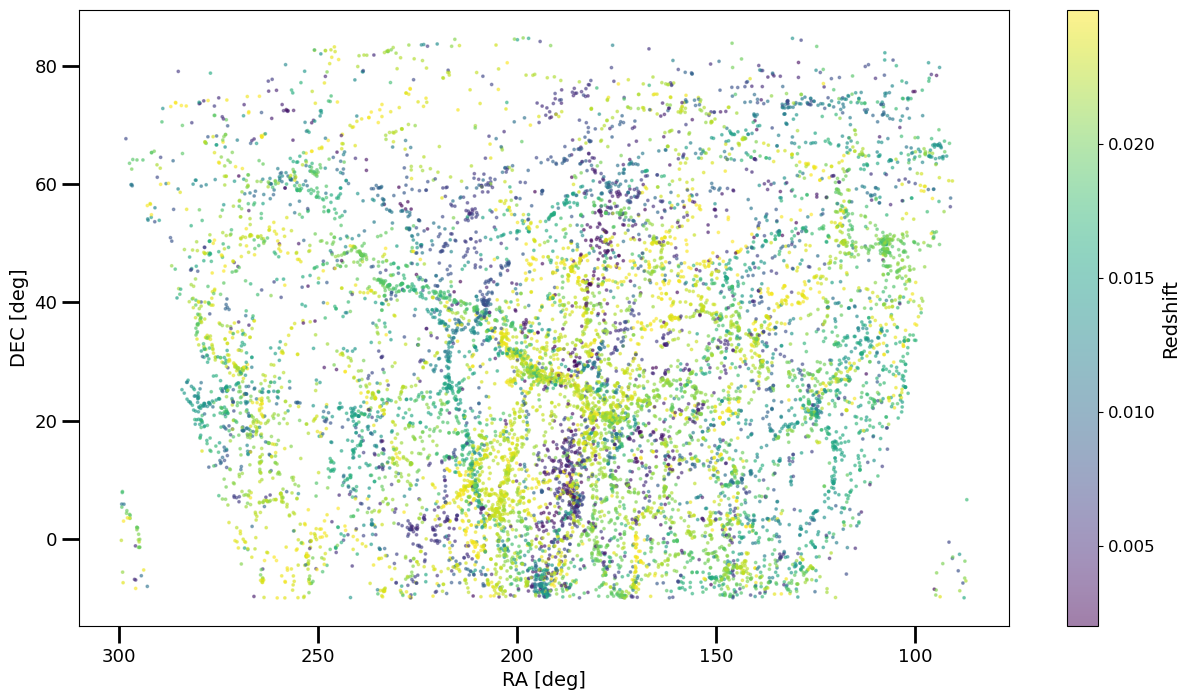

In [253]:
fig, ax = plt.subplots(figsize=(15,8))
ax.invert_xaxis()

dat2 = ax.scatter(sga2025_z['RA'][raflag&decflag&(snr_ap01_flag | snr_ap03_flag)], 
                  sga2025_z['DEC'][raflag&decflag&(snr_ap01_flag | snr_ap03_flag)], 
                  c=sga2025_z['Z'][raflag&decflag&(snr_ap01_flag | snr_ap03_flag)], alpha=0.5, s=3)

cbar = fig.colorbar(dat2, ax=ax)
cbar.set_label('Redshift', size=14)
cbar.ax.tick_params(labelsize=12)

ax.tick_params(axis='x', length=12, width=2, labelsize=13)
ax.tick_params(axis='y', length=12, width=2, labelsize=13)
ax.set_xlabel('RA [deg]',fontsize=14)
ax.set_ylabel('DEC [deg]',fontsize=14)

plt.show()

In [262]:
#trim phot, make row-matched to wisesize parent sample

wisesize_phot = join(wisesize, phot, keys='SGAID', join_type='left')

In [268]:
#apply RA+DEC, SNRW3_AP01 U SNRW3_AP03 flags to create a galfit_sample_flag
wisesize['galfit_sample_flag'] = raflag&decflag&(snr_ap01_flag | snr_ap03_flag)
wisesize_phot['galfit_sample_flag'] = raflag&decflag&(snr_ap01_flag | snr_ap03_flag)

In [267]:
#save tables
wisesize.write(homedir+'/Desktop/wisesize/wisesize_parent_v0.fits', overwrite=True)
wisesize_phot.write(homedir+'/Desktop/wisesize/wisesize_phot_v0.fits', overwrite=True)

In [272]:
#create galfit sample, save tables
wisesize[wisesize['galfit_sample_flag']].write(homedir+'/Desktop/wisesize/wisesize_galfit_parent_v0.fits',
                                               overwrite=True)
wisesize_phot[wisesize['galfit_sample_flag']].write(homedir+'/Desktop/wisesize/wisesize_galfit_phot_v0.fits',
                                                    overwrite=True)